In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
df = pd.read_csv("q1.csv", header=None)
df.describe()
df.head()

,0
0,0.8402
1,1.0644
2,1.1298
3,1.4314
4,1.7795


In [3]:
#Assessing goodness of fit to Weibull using Q-Q plot

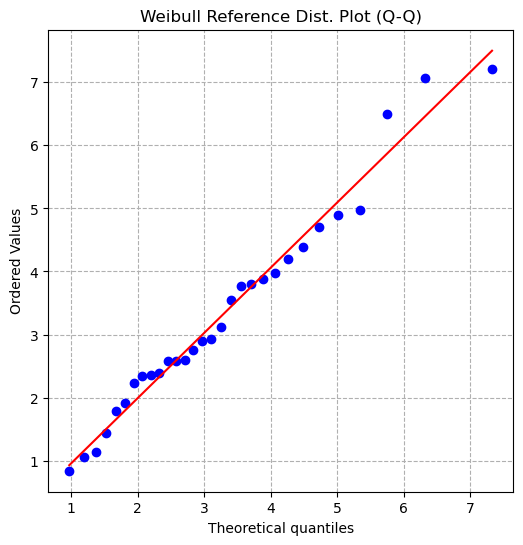

In [4]:
shape, loc, scale = stats.weibull_min.fit(df)
plt.figure(figsize=(6,6))
stats.probplot(df[0], sparams=(shape, loc, scale), dist="weibull_min", plot=plt)
plt.title("Weibull Reference Dist. Plot (Q-Q)")
plt.grid(True, linestyle='--')
plt.show()

In [5]:
#Formal GoF via Anderson-Darling

In [6]:
AD = stats.anderson_ksamp([df[0], stats.weibull_min.rvs(shape, loc, scale, size = 1000)])

C:\Users\jmeek\AppData\Local\Temp\ipykernel_7528\506921784.py:1: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  AD = stats.anderson_ksamp([df[0], stats.weibull_min.rvs(shape, loc, scale, size = 1000)])


In [7]:
AD.pvalue #Capped at 0.25, but passes

np.float64(0.25)

In [8]:
#Testing uncapped P-value
AD = stats.anderson_ksamp([df[0], stats.weibull_min.rvs(shape, loc, scale, size = 1000)], method = stats.PermutationMethod(n_resamples=2000))

In [9]:
AD.pvalue

np.float64(0.9720139930034982)